### Notebook 2: Exploratory Data Analysis (EDA)

**Objectives:**
- Temporal demand patterns: intraday cycles, weekday vs weekend
- Station utilization distribution: overloaded vs underutilized
- Peak and off-peak profiling across time slots
- Price vs demand relationship
- ACN session behavior: energy, duration, idle time

**All plots are saved to `plots/` for direct use in the presentation deck.**

**Note:** Observations are descriptive. No causal claims are made.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.dpi'] = 130

# Hardcoded project root — same for all notebooks
BASE  = r"C:\Users\hp\OneDrive\Desktop\EV_Tariff_Optimization"
PROC  = os.path.join(BASE, "data", "processed") + "\\"
PLOTS = os.path.join(BASE, "plots") + "\\"
OUT   = os.path.join(BASE, "outputs") + "\\"

print(f"PROC  : {PROC}")
print(f"PLOTS : {PLOTS}")
print(f"OUT   : {OUT}")

acn      = pd.read_csv(PROC + "acn_processed.csv",
                        parse_dates=['connection_time','disconnect_time','done_charging_time'])
panel    = pd.read_csv(PROC + "urbanev_panel.csv",   parse_dates=['datetime'])
util_df  = pd.read_csv(PROC + "utilization_matrix.csv", index_col=0, parse_dates=True)
price_df = pd.read_csv(PROC + "price_matrix.csv",       index_col=0, parse_dates=True)

print(f"ACN    : {acn.shape}")
print(f"Panel  : {panel.shape}")
print(f"Util   : {util_df.shape}")
print(f"Price  : {price_df.shape}")
print(" Data loaded successfully")

PROC  : C:\Users\hp\OneDrive\Desktop\EV_Tariff_Optimization\data\processed\
PLOTS : C:\Users\hp\OneDrive\Desktop\EV_Tariff_Optimization\plots\
OUT   : C:\Users\hp\OneDrive\Desktop\EV_Tariff_Optimization\outputs\
ACN    : (14848, 21)
Panel  : (432000, 22)
Util   : (8640, 247)
Price  : (8640, 247)
 Data loaded successfully


### 2.1 ACN — Hourly Session Volume & Energy Demand

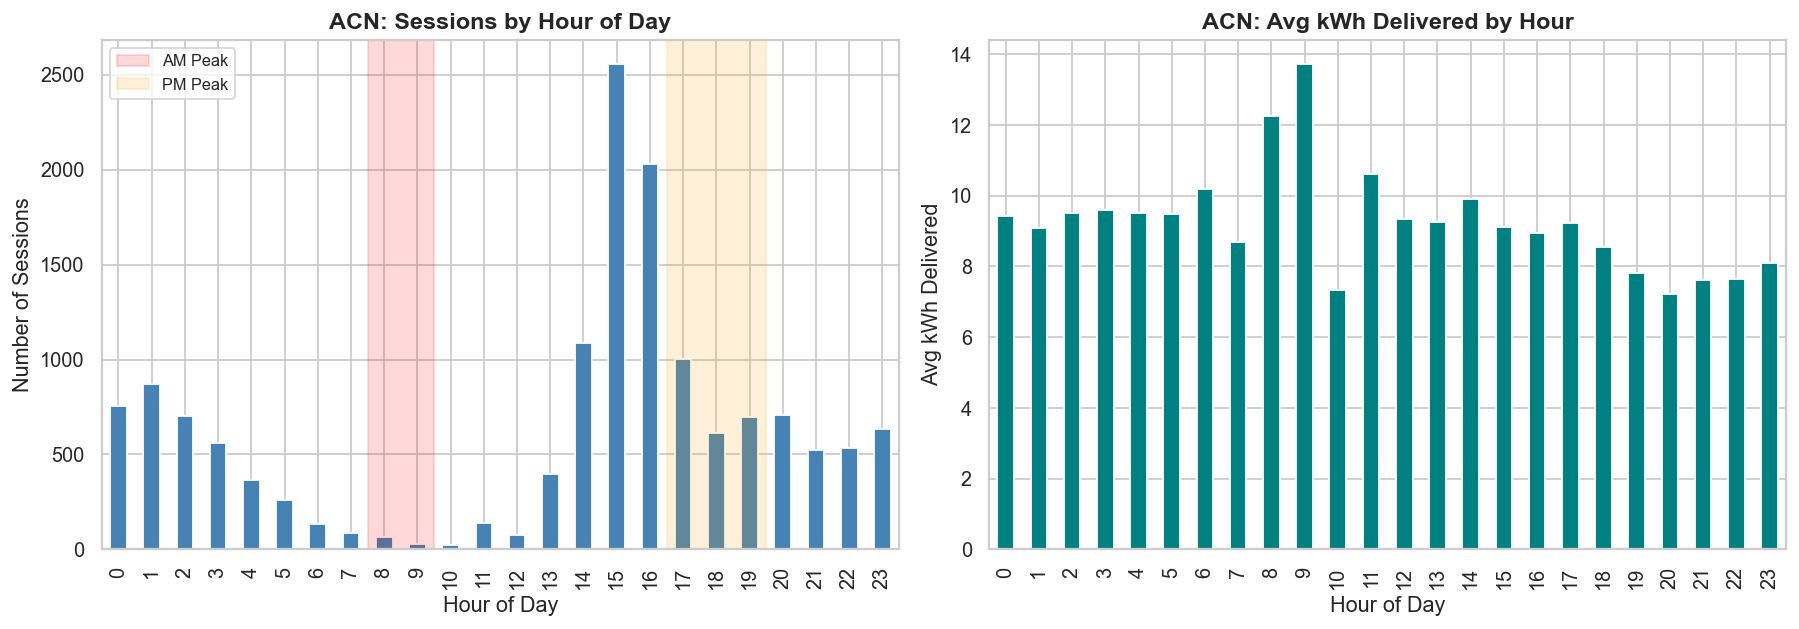

 Saved: acn_hourly_demand.png


In [2]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

acn.groupby('hour').size().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('ACN: Sessions by Hour of Day', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Number of Sessions')
axes[0].axvspan(7.5,  9.5,  alpha=0.15, color='red',    label='AM Peak')
axes[0].axvspan(16.5, 19.5, alpha=0.15, color='orange', label='PM Peak')
axes[0].legend(fontsize=9)

acn.groupby('hour')['kwh_delivered'].mean().plot(
    kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('ACN: Avg kWh Delivered by Hour', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Avg kWh Delivered')

plt.tight_layout()
plt.savefig(PLOTS + "acn_hourly_demand.png", bbox_inches='tight')
plt.show()
print(" Saved: acn_hourly_demand.png")

### 2.2 ACN — Weekday vs Weekend Patterns

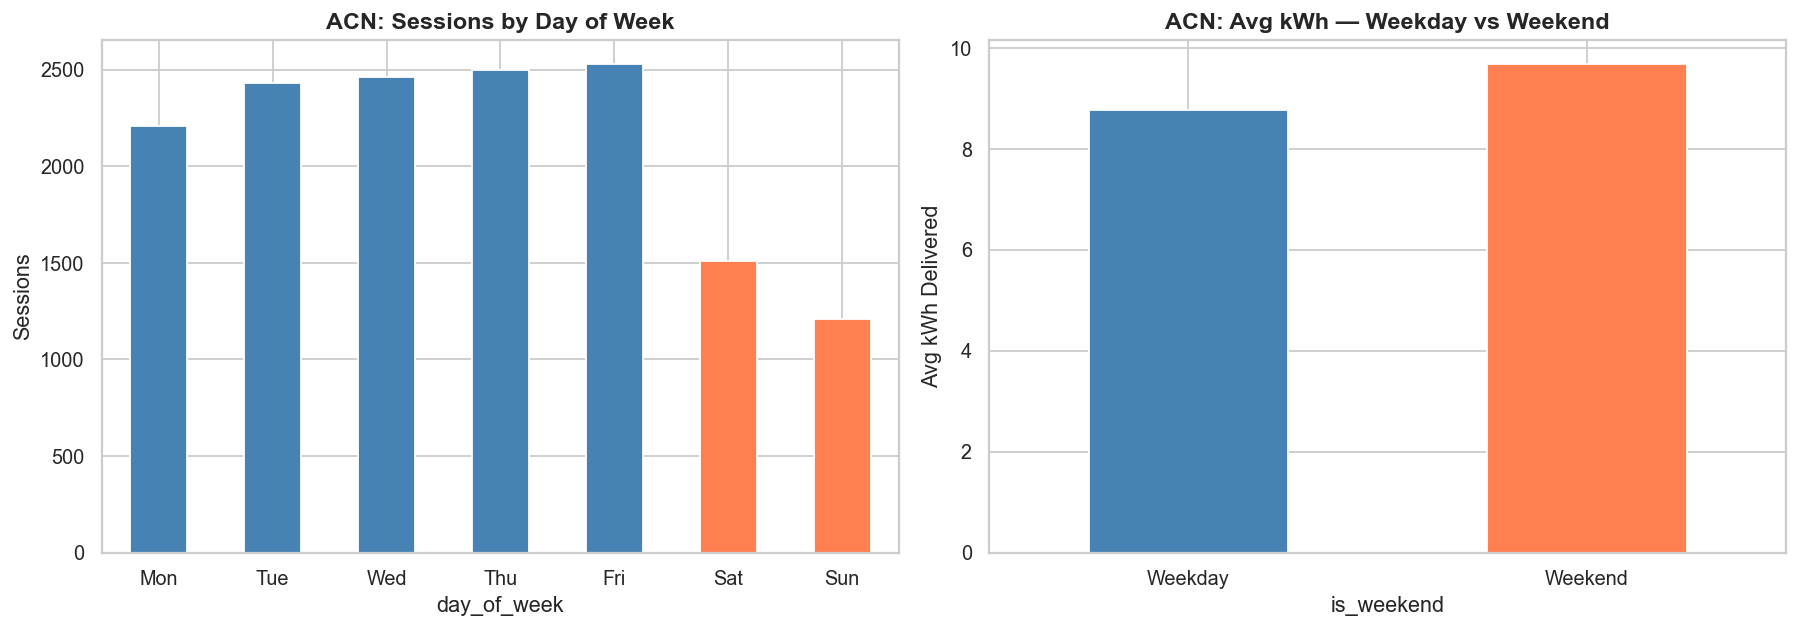

 Saved: acn_weekday_weekend.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
day_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

acn.groupby('day_of_week').size().plot(
    kind='bar', ax=axes[0],
    color=['steelblue']*5 + ['coral']*2, edgecolor='white')
axes[0].set_title('ACN: Sessions by Day of Week', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(day_labels, rotation=0)
axes[0].set_ylabel('Sessions')

acn.groupby('is_weekend')['kwh_delivered'].mean().plot(
    kind='bar', ax=axes[1],
    color=['steelblue','coral'], edgecolor='white')
axes[1].set_title('ACN: Avg kWh — Weekday vs Weekend', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(['Weekday','Weekend'], rotation=0)
axes[1].set_ylabel('Avg kWh Delivered')

plt.tight_layout()
plt.savefig(PLOTS + "acn_weekday_weekend.png", bbox_inches='tight')
plt.show()
print(" Saved: acn_weekday_weekend.png")

### 2.3 ACN — Session Duration, Energy & Idle Time Distributions

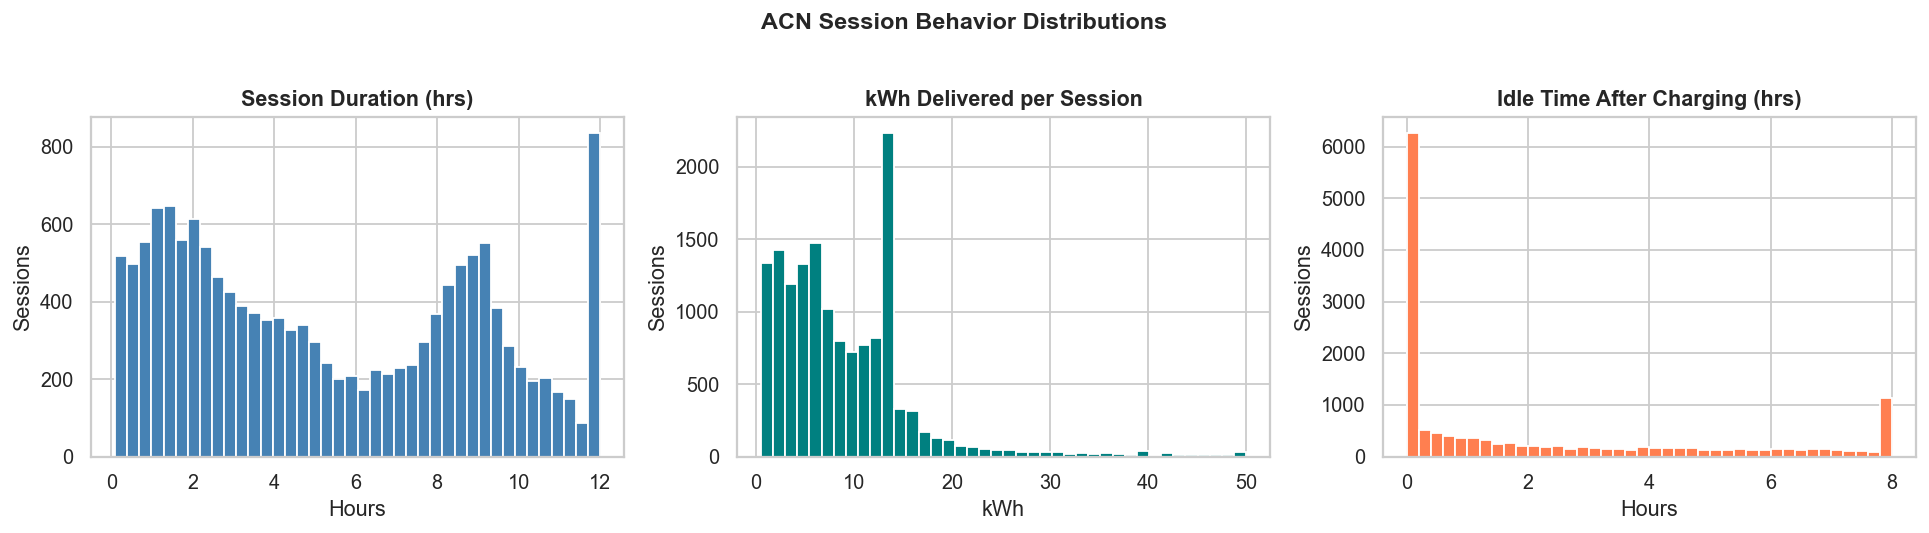

 Saved: acn_session_distributions.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

acn['session_duration_hr'].clip(0, 12).hist(
    bins=40, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Session Duration (hrs)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Sessions')

acn['kwh_delivered'].clip(0, 50).hist(
    bins=40, ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('kWh Delivered per Session', fontsize=12, fontweight='bold')
axes[1].set_xlabel('kWh')
axes[1].set_ylabel('Sessions')

acn['idle_time_hr'].clip(0, 8).hist(
    bins=40, ax=axes[2], color='coral', edgecolor='white')
axes[2].set_title('Idle Time After Charging (hrs)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Sessions')

plt.suptitle('ACN Session Behavior Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(PLOTS + "acn_session_distributions.png", bbox_inches='tight')
plt.show()
print(" Saved: acn_session_distributions.png")

### 2.4 ST-EVCDP — Network-Wide Utilization Over Time

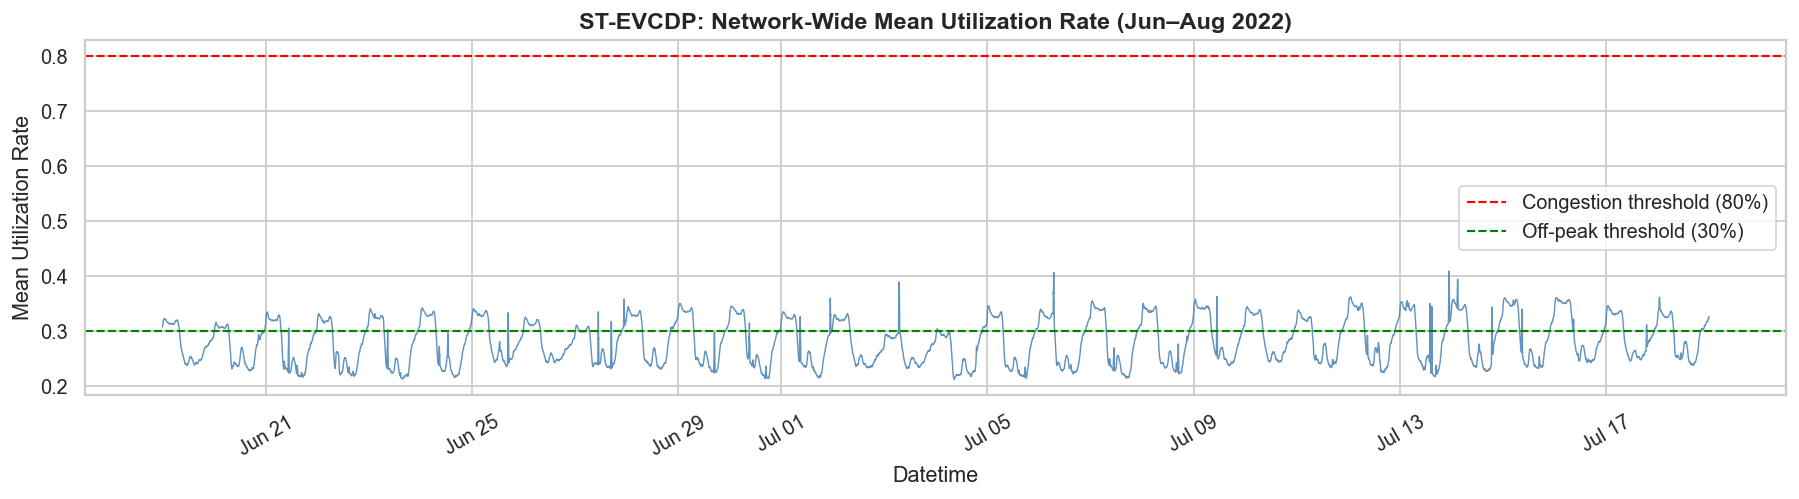

 Saved: urbanev_mean_utilization.png


In [5]:
mean_util = util_df.mean(axis=1)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(mean_util.index, mean_util.values, color='steelblue', lw=0.8, alpha=0.85)
ax.axhline(0.8, color='red',   ls='--', lw=1.2, label='Congestion threshold (80%)')
ax.axhline(0.3, color='green', ls='--', lw=1.2, label='Off-peak threshold (30%)')
ax.set_title('ST-EVCDP: Network-Wide Mean Utilization Rate (Jun–Aug 2022)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Mean Utilization Rate')
ax.set_xlabel('Datetime')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(PLOTS + "urbanev_mean_utilization.png", bbox_inches='tight')
plt.show()
print(" Saved: urbanev_mean_utilization.png")

###  2.5 ST-EVCDP — Intraday Utilization & Volume Profile

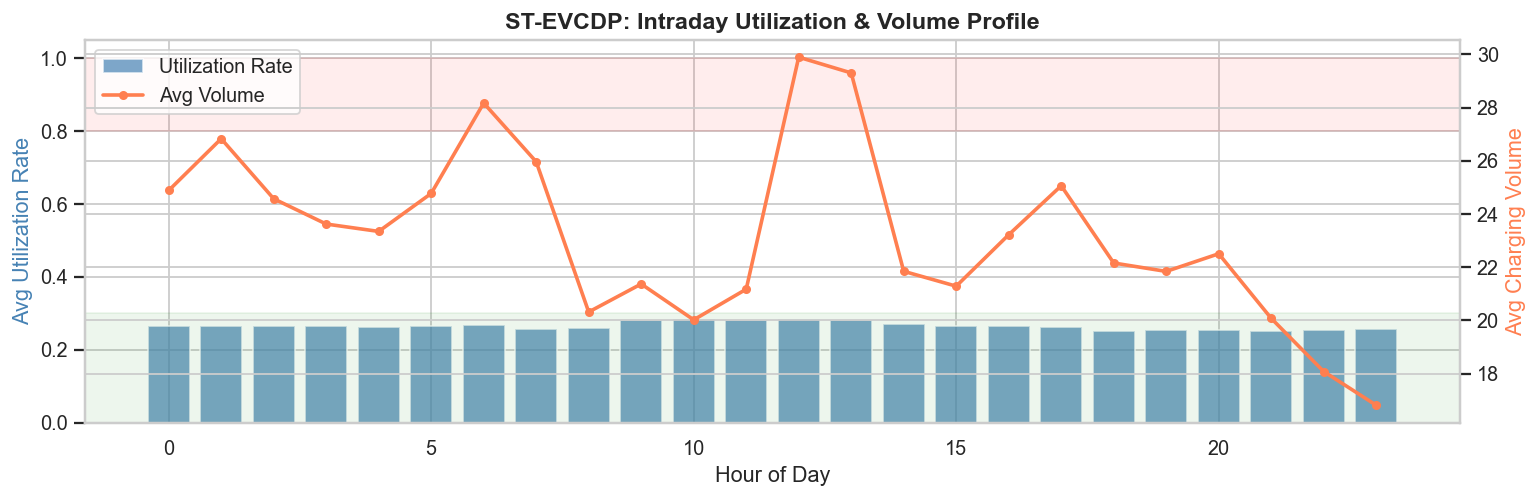

 Saved: urbanev_intraday_profile.png


In [6]:
hourly_util = panel.groupby('hour')['utilization'].mean()
hourly_vol  = panel.groupby('hour')['volume'].mean()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()

ax1.bar(hourly_util.index, hourly_util.values,
        color='steelblue', alpha=0.7, label='Utilization Rate')
ax2.plot(hourly_vol.index, hourly_vol.values,
         color='coral', lw=2, marker='o', ms=4, label='Avg Volume')

ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Avg Utilization Rate', color='steelblue')
ax2.set_ylabel('Avg Charging Volume',  color='coral')
ax1.set_title('ST-EVCDP: Intraday Utilization & Volume Profile',
              fontsize=13, fontweight='bold')
ax1.axhspan(0,   0.3, alpha=0.07, color='green')
ax1.axhspan(0.8, 1.0, alpha=0.07, color='red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+lines2, labels1+labels2, loc='upper left')
plt.tight_layout()
plt.savefig(PLOTS + "urbanev_intraday_profile.png", bbox_inches='tight')
plt.show()
print(" Saved: urbanev_intraday_profile.png")

### 2.6 Station Utilization Distribution — Overloaded vs Underutilized

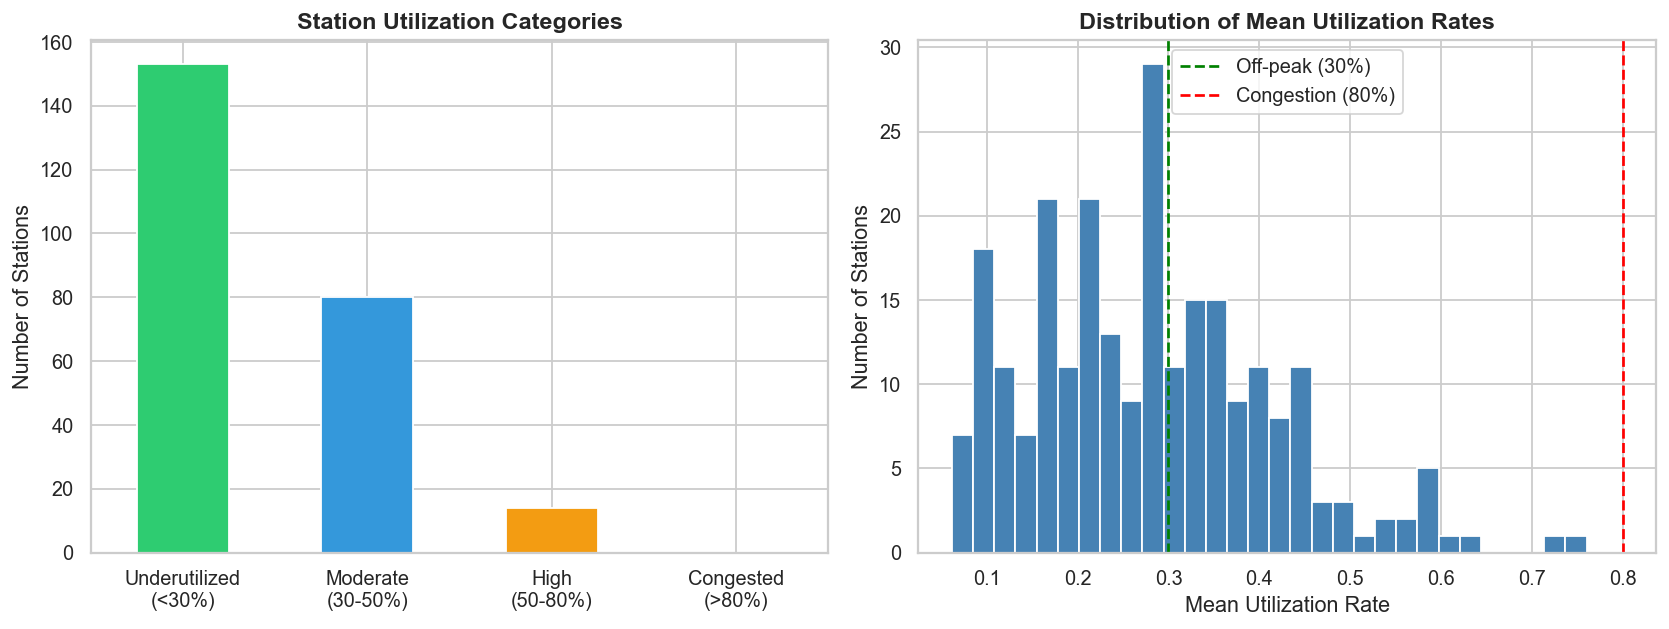

 Saved: station_utilization_distribution.png
 Saved: station_utilization_ranking.csv


In [7]:
mean_util_per_station = util_df.mean()
bins     = [0, 0.3, 0.5, 0.8, 1.0]
labels_b = ['Underutilized\n(<30%)', 'Moderate\n(30-50%)', 'High\n(50-80%)', 'Congested\n(>80%)']
cat        = pd.cut(mean_util_per_station, bins=bins, labels=labels_b)
cat_counts = cat.value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cat_counts.plot(kind='bar', ax=axes[0],
                color=['#2ecc71','#3498db','#f39c12','#e74c3c'], edgecolor='white')
axes[0].set_title('Station Utilization Categories', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Stations')
axes[0].set_xticklabels(labels_b, rotation=0)

mean_util_per_station.hist(bins=30, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].axvline(0.3, color='green', ls='--', lw=1.5, label='Off-peak (30%)')
axes[1].axvline(0.8, color='red',   ls='--', lw=1.5, label='Congestion (80%)')
axes[1].set_title('Distribution of Mean Utilization Rates', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean Utilization Rate')
axes[1].set_ylabel('Number of Stations')
axes[1].legend()

plt.tight_layout()
plt.savefig(PLOTS + "station_utilization_distribution.png", bbox_inches='tight')
plt.show()

util_ranking = mean_util_per_station.reset_index()
util_ranking.columns = ['station_id', 'mean_utilization']
util_ranking['category'] = pd.cut(
    util_ranking['mean_utilization'], bins=bins,
    labels=['Underutilized','Moderate','High','Congested']
)
util_ranking = util_ranking.sort_values('mean_utilization', ascending=False)
util_ranking.to_csv(OUT + "station_utilization_ranking.csv", index=False)
print(" Saved: station_utilization_distribution.png")
print(" Saved: station_utilization_ranking.csv")

### 2.7 Price vs Utilization Relationship

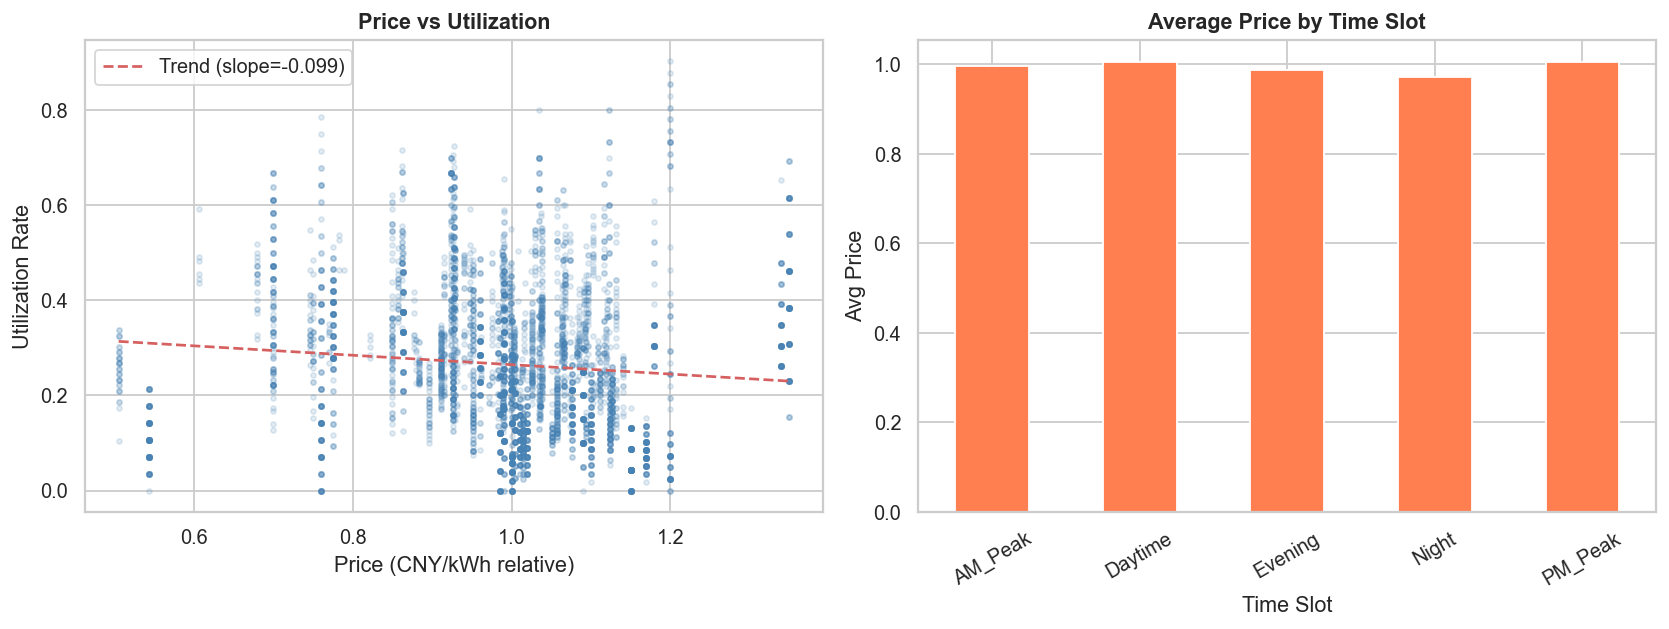

 Saved: price_vs_utilization.png


In [8]:
sample = panel.dropna(subset=['price','utilization']).sample(
    min(5000, len(panel)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(sample['price'], sample['utilization'],
                alpha=0.15, s=8, color='steelblue')
z  = np.polyfit(sample['price'], sample['utilization'], 1)
p  = np.poly1d(z)
xp = np.linspace(sample['price'].min(), sample['price'].max(), 100)
axes[0].plot(xp, p(xp), 'r--', lw=1.5, label=f'Trend (slope={z[0]:.3f})')
axes[0].set_xlabel('Price (CNY/kWh relative)')
axes[0].set_ylabel('Utilization Rate')
axes[0].set_title('Price vs Utilization', fontsize=12, fontweight='bold')
axes[0].legend()

panel.groupby('time_slot')['price'].mean().plot(
    kind='bar', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Price by Time Slot', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Time Slot')
axes[1].set_ylabel('Avg Price')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(PLOTS + "price_vs_utilization.png", bbox_inches='tight')
plt.show()
print(" Saved: price_vs_utilization.png")

### 2.8 Heatmap — Utilization by Hour and Day of Week
**Insight:** 2D demand map directly informs which hour × day combinations need surge vs discount pricing.

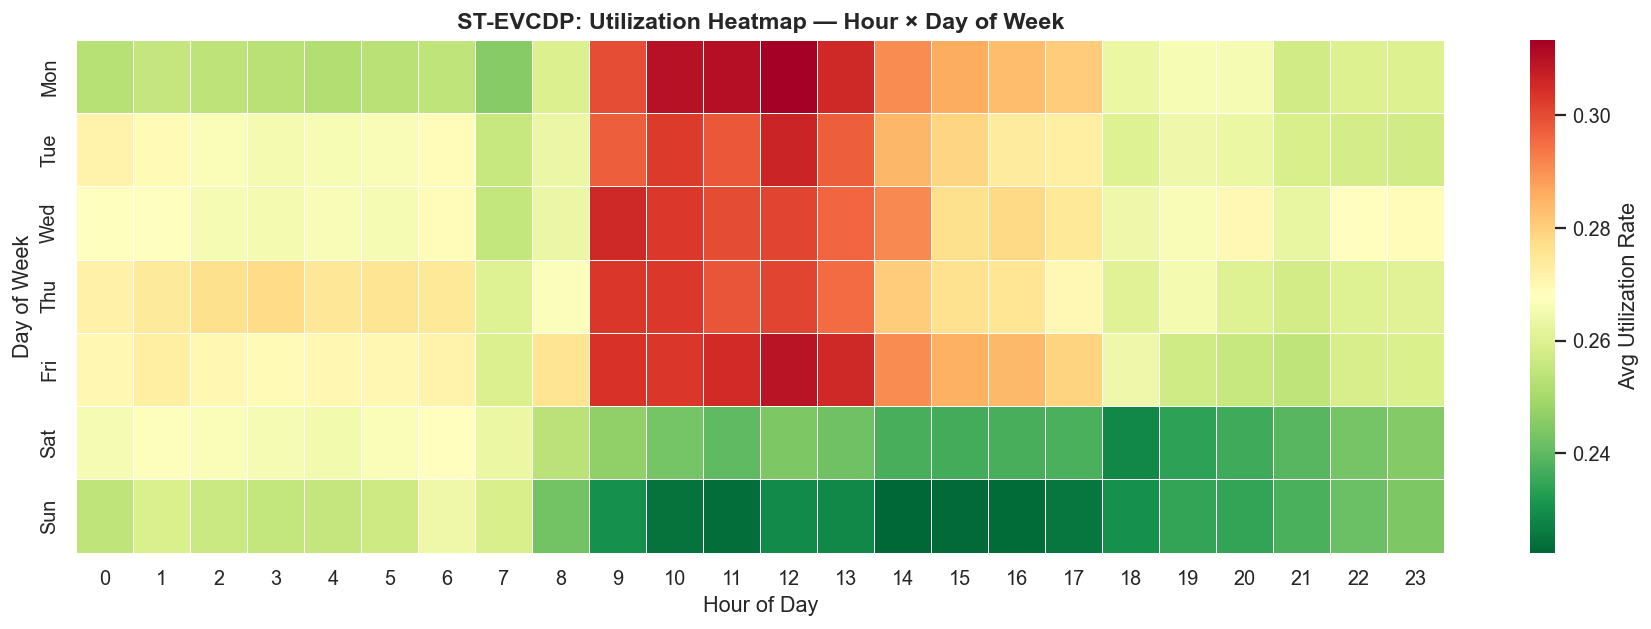

 Saved: utilization_heatmap.png


In [9]:
panel['day_of_week'] = panel['datetime'].dt.dayofweek
heatmap_data = panel.groupby(['day_of_week','hour'])['utilization'].mean().unstack()
heatmap_data.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='RdYlGn_r', ax=ax,
            linewidths=0.3, annot=False,
            cbar_kws={'label': 'Avg Utilization Rate'})
ax.set_title('ST-EVCDP: Utilization Heatmap — Hour × Day of Week',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Day of Week')
plt.tight_layout()
plt.savefig(PLOTS + "utilization_heatmap.png", bbox_inches='tight')
plt.show()
print(" Saved: utilization_heatmap.png")

### 2.9 EDA Summary Statistics

In [10]:
mean_util_per_station = util_df.mean()

eda_summary = pd.DataFrame({
    'Metric': [
        'ACN: Total Sessions',
        'ACN: Total kWh Delivered',
        'ACN: Avg Session Duration (hrs)',
        'ACN: Avg Idle Time After Charging (hrs)',
        'ACN: Peak Hour (most sessions)',
        'ACN: Weekend Sessions %',
        'UrbanEV: Stations Analysed',
        'UrbanEV: Mean Network Utilization Rate',
        'UrbanEV: Congested Station-Timesteps %',
        'UrbanEV: Off-Peak Station-Timesteps %',
        'UrbanEV: Stations Underutilized (<30%)',
        'UrbanEV: Stations Congested (>80%)'
    ],
    'Value': [
        f"{acn.shape[0]:,}",
        f"{acn['kwh_delivered'].sum():,.0f} kWh",
        f"{acn['session_duration_hr'].mean():.2f} hrs",
        f"{acn['idle_time_hr'].mean():.2f} hrs",
        f"{acn.groupby('hour').size().idxmax()}:00",
        f"{acn['is_weekend'].mean()*100:.1f}%",
        f"{util_df.shape[1]}",
        f"{util_df.mean().mean():.2%}",
        f"{(util_df > 0.8).mean().mean()*100:.2f}%",
        f"{(util_df < 0.3).mean().mean()*100:.2f}%",
        f"{(mean_util_per_station < 0.3).sum()}",
        f"{(mean_util_per_station > 0.8).sum()}"
    ]
})

eda_summary.to_csv(OUT + "eda_summary.csv", index=False)
print(eda_summary.to_string(index=False))
print("\n Notebook 2 complete, Run Notebook 3 next.")

                                 Metric       Value
                    ACN: Total Sessions      14,848
               ACN: Total kWh Delivered 132,782 kWh
        ACN: Avg Session Duration (hrs)    5.50 hrs
ACN: Avg Idle Time After Charging (hrs)    2.34 hrs
         ACN: Peak Hour (most sessions)       15:00
                ACN: Weekend Sessions %       18.3%
             UrbanEV: Stations Analysed         247
 UrbanEV: Mean Network Utilization Rate      28.02%
 UrbanEV: Congested Station-Timesteps %       1.02%
  UrbanEV: Off-Peak Station-Timesteps %      60.85%
 UrbanEV: Stations Underutilized (<30%)         153
     UrbanEV: Stations Congested (>80%)           0

 Notebook 2 complete, Run Notebook 3 next.
